In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report 
from sklearn import metrics
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import os
os.chdir("/Users/AlanHDLR/Desktop")

In [79]:
drugs = pd.read_csv("drugs.csv")
num_drugs = drugs['Drug'].value_counts()
print(drugs)
print("-------------------------------------------------------")
print("Cantidad de pacientes tratados por medicamento:",num_apps_in_category)
print("-------------------------------------------------------")
print("Total de pacientes:",sum(num_apps_in_category))

     Age Sex      BP Cholesterol  Na_to_K   Drug
0     23   F    HIGH        HIGH   25.355  drugY
1     47   M     LOW        HIGH   13.093  drugC
2     47   M     LOW        HIGH   10.114  drugC
3     28   F  NORMAL        HIGH    7.798  drugX
4     61   F     LOW        HIGH   18.043  drugY
..   ...  ..     ...         ...      ...    ...
195   56   F     LOW        HIGH   11.567  drugC
196   16   M     LOW        HIGH   12.006  drugC
197   52   M  NORMAL        HIGH    9.894  drugX
198   23   M  NORMAL      NORMAL   14.020  drugX
199   40   F     LOW      NORMAL   11.349  drugX

[200 rows x 6 columns]
-------------------------------------------------------
Cantidad de pacientes tratados por medicamento: Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64
-------------------------------------------------------
Total de pacientes: 200


In [5]:
# Columnas de referencia
feature_cols = ["Age", "Sex", "BP", "Cholesterol", "Na_to_K"]
X = drugs[feature_cols].values
y = drugs.Drug

In [7]:
# Preprocesamiento para las variables categoricas
from sklearn import preprocessing

# Columna Sex
Cod_sex = preprocessing.LabelEncoder()
Cod_sex.fit(["F", "M"])
X[:,1] = Cod_sex.transform(X[:,1])

# Columna BP
Cod_bp = preprocessing.LabelEncoder()
Cod_bp.fit(["HIGH", "NORMAL", "LOW"])
X[:,2] = Cod_bp.transform(X[:,2])

# Columna Cholesterol
Cod_cholesterol = preprocessing.LabelEncoder()
Cod_cholesterol.fit(["HIGH", "NORMAL"])
X[:,3] = Cod_cholesterol.transform(X[:,3])

In [9]:
X[0:5]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

In [11]:
y[0:5]

0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: object

In [13]:
# CReación de grupos de entrenamiento y prueba 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

# Regresión logística con Solucionador (Solver): sag

In [16]:
model = LogisticRegression(solver = "sag")
clf = model.fit(X_train, y_train)

In [18]:
# Predicción de etiquetas de clase sobre datos de prueba
y_pred = model.predict(X_test)

# Impresión de coeficientes de la regresión de puntajes 
print("Intercepto (Beta 0)", clf.intercept_)
print("Pesos de cada variable:", clf.coef_)

Intercepto (Beta 0) [ 0.25344016 -0.085858    0.0860967   0.23590568 -0.48958454]
Pesos de cada variable: [[-0.02572012  0.15573473 -0.63524688  0.07877528  0.1030866 ]
 [ 0.06832498 -0.06130223 -0.51825693 -0.08968183 -0.28082165]
 [-0.00480969  0.00627513  0.1571542  -0.2593347  -0.0070638 ]
 [ 0.01460329 -0.07017975  1.15274736  0.4283676  -0.11918414]
 [-0.05239847 -0.03052789 -0.15639775 -0.15812635  0.30398299]]


In [20]:
# Evaluación de la precisión del modelo
score = model.score(X_test, y_test)
print("Score de precisión: ", score)

Score de precisión:  0.7666666666666667


In [22]:
# Reporte de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       drugA       0.50      0.25      0.33         4
       drugB       0.57      0.67      0.62         6
       drugC       0.00      0.00      0.00         4
       drugX       0.84      0.84      0.84        19
       drugY       0.78      0.93      0.85        27

    accuracy                           0.77        60
   macro avg       0.54      0.54      0.53        60
weighted avg       0.71      0.77      0.73        60



# Regresión logística con Solucionador (Solver): newton-cg

In [103]:
model = LogisticRegression(solver = "newton-cg")
clf = model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intecepto (Beta0): ", clf.intercept_)
print("Pesos (Betas): ", clf.coef_)
print("-------------------------------------------------------------------------")
score = model.score(X_test, y_test)
print("Precisión global: ", score)
print("-------------------------------------------------------------------------")
print(classification_report(y_test, y_pred))

Intecepto (Beta0):  [ 14.26521435   0.35743672   9.95249269   6.20153465 -30.77667841]
Pesos (Betas):  [[-0.08775581  0.08138316 -2.30264064 -0.30840785 -0.63833143]
 [ 0.1369387  -0.14851031 -1.59673009 -0.2136584  -0.46475879]
 [-0.03054689 -0.02842968  0.59670301 -1.40278854 -0.57106352]
 [-0.00524926 -0.33752467  2.90195439  1.76686661 -0.5721832 ]
 [-0.01338674  0.4330815   0.40071332  0.15798818  2.24633694]]
-------------------------------------------------------------------------
Precisión global:  0.95
-------------------------------------------------------------------------
              precision    recall  f1-score   support

       drugA       0.80      1.00      0.89         4
       drugB       0.71      0.83      0.77         6
       drugC       1.00      0.50      0.67         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.95        60
   macro avg       0.90      

# Regresión logística con Solucionador (Solver): liblinear

In [27]:
model = LogisticRegression(solver = "liblinear")
clf = model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intecepto (Beta0): ", clf.intercept_)
print("Pesos (Betas): ", clf.coef_)
print("-------------------------------------------------------------------------")
score = model.score(X_test, y_test)
print("Precisión global: ", score)
print("-------------------------------------------------------------------------")
print(classification_report(y_test, y_pred))

Intecepto (Beta0):  [ 2.29334919 -0.70467035  0.58924019  0.30109865 -4.29114991]
Pesos (Betas):  [[-0.02412566  0.42217358 -2.29714996 -0.23214111 -0.16660789]
 [ 0.10577261 -0.5134536  -2.3102013  -0.72467248 -0.43448448]
 [-0.00480855  0.02687672  0.02971114 -1.73320841 -0.17340814]
 [ 0.01454251 -0.61675951  2.82426364  2.09429217 -0.44362   ]
 [-0.04103855  0.160339   -0.24330771 -0.35868153  0.42573623]]
-------------------------------------------------------------------------
Precisión global:  0.85
-------------------------------------------------------------------------
              precision    recall  f1-score   support

       drugA       0.75      0.75      0.75         4
       drugB       0.62      0.83      0.71         6
       drugC       0.00      0.00      0.00         4
       drugX       0.83      1.00      0.90        19
       drugY       0.96      0.89      0.92        27

    accuracy                           0.85        60
   macro avg       0.63      0.69 

# Regresión logística con Solucionador (Solver): saga

In [30]:
model = LogisticRegression(solver = "saga")
clf = model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intecepto (Beta0): ", clf.intercept_)
print("Pesos (Betas): ", clf.coef_)
print("-------------------------------------------------------------------------")
score = model.score(X_test, y_test)
print("Precisión global: ", score)
print("-------------------------------------------------------------------------")
print(classification_report(y_test, y_pred))

Intecepto (Beta0):  [ 0.12849394 -0.05372332  0.04262132  0.14223871 -0.25963064]
Pesos (Betas):  [[-0.0234378   0.08635096 -0.3756486   0.04523923  0.09131705]
 [ 0.06100888 -0.03255155 -0.31234003 -0.0462093  -0.26706799]
 [-0.00440818  0.00301992  0.07657441 -0.1409945  -0.0107512 ]
 [ 0.01865412 -0.0358705   0.73812571  0.23211444 -0.09109816]
 [-0.05181702 -0.02094882 -0.12671149 -0.09014987  0.2776003 ]]
-------------------------------------------------------------------------
Precisión global:  0.7166666666666667
-------------------------------------------------------------------------
              precision    recall  f1-score   support

       drugA       0.00      0.00      0.00         4
       drugB       0.67      0.67      0.67         6
       drugC       0.00      0.00      0.00         4
       drugX       0.70      0.74      0.72        19
       drugY       0.74      0.93      0.82        27

    accuracy                           0.72        60
   macro avg       0

# Regresión logística con Solucionador (Solver): lbfgs

In [92]:
model = LogisticRegression(solver = "lbfgs")
clf = model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intecepto (Beta0): ", clf.intercept_)
print("Pesos (Betas): ", clf.coef_)
print("-------------------------------------------------------------------------")
score = model.score(X_test, y_test)
print("Precisión global: ", score)
print("-------------------------------------------------------------------------")
print(classification_report(y_test, y_pred))

Intecepto (Beta0):  [ 1.90277659 -0.51428571  0.89891801  1.04752395 -3.33493285]
Pesos (Betas):  [[-0.02582009  0.56005755 -2.56625296 -0.10787923  0.04669552]
 [ 0.09675321 -0.41418652 -2.1526951  -0.64802    -0.25378448]
 [-0.01303483  0.054748    1.11979765 -1.44352475 -0.02894026]
 [-0.01150409 -0.54596894  3.01309399  2.5308087  -0.24822761]
 [-0.04639419  0.34534991  0.58605642 -0.33138473  0.48425683]]
-------------------------------------------------------------------------
Precisión global:  0.8666666666666667
-------------------------------------------------------------------------
              precision    recall  f1-score   support

       drugA       0.60      0.75      0.67         4
       drugB       0.67      0.67      0.67         6
       drugC       1.00      0.50      0.67         4
       drugX       0.90      0.95      0.92        19
       drugY       0.93      0.93      0.93        27

    accuracy                           0.87        60
   macro avg       0

In [121]:
# Predicción de probabilidades para casos particulares 

# 1. Obtén las probabilidades de todas las clases (sin el [:, 1])
y_pred_probs_all = clf.predict_proba(X_test)

# 2. Míralas junto a sus nombres para que sea claro
import pandas as pd
df_probs = pd.DataFrame(y_pred_probs_all, columns=clf.classes_)

# 3. Compara los primeros 5 con el valor real
df_probs['Valor_Real'] = y_test
print(df_probs.head())

          drugA         drugB         drugC         drugX         drugY  \
0  6.598482e-05  8.902622e-04  5.337605e-03  9.937058e-01  3.477286e-07   
1  5.964780e-10  8.340299e-07  6.254430e-07  9.165583e-06  9.999894e-01   
2  5.457564e-04  2.802406e-03  1.159710e-01  7.565284e-01  1.241524e-01   
3  1.852700e-01  1.803774e-03  5.409417e-01  2.549941e-01  1.699044e-02   
4  2.461041e-28  8.144131e-30  1.126575e-28  4.003278e-30  1.000000e+00   

  Valor_Real  
0      drugX  
1      drugY  
2      drugX  
3      drugC  
4      drugY  


# NOTA
### Como en este ejercicio no habia solo 1 variable a la cual diagnosticar si era más cercana a 1 o 0, tuve que analizar los datos por medicamento
### Obtuve las primeros 5 valores predecidos y tuve que observar cuales eran los más cercanos a 1, si bien se pueden observar valores mas grandes que 1, esto se debe a que estan expresados en notación científica, por ejemplo el primer valor de la columna B no es un "8.902622" si no en realidad "0.0008902622", aplicando esta transformación a cada valor, obtuve que las predicciones del modelo dicen que:

* Paciente 1: "DrugX"
* Paciente 2: "DrugY"
* Paciente 3: "DrugX"
* Paciente 4: "DrugC"
* Paciente 5: "DrugY"

### Y observando el valir real, podemos notar que acerto en 5 de los 5 primeros pacientes 

In [105]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Convertimos las etiquetas a formato binario (5 columnas)
y_test_bin = label_binarize(y_test, classes=clf.classes_)
n_classes = len(clf.classes_)

# Obtenemos todas las probabilidades (la matriz completa)
y_score = clf.predict_proba(X_test)

In [107]:
# Guardamos los resultados
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Cálculo del AUC promedio
auc_macro = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
print(f"AUC Global (Macro-average): {auc_macro:.2f}")

AUC Global (Macro-average): 0.99


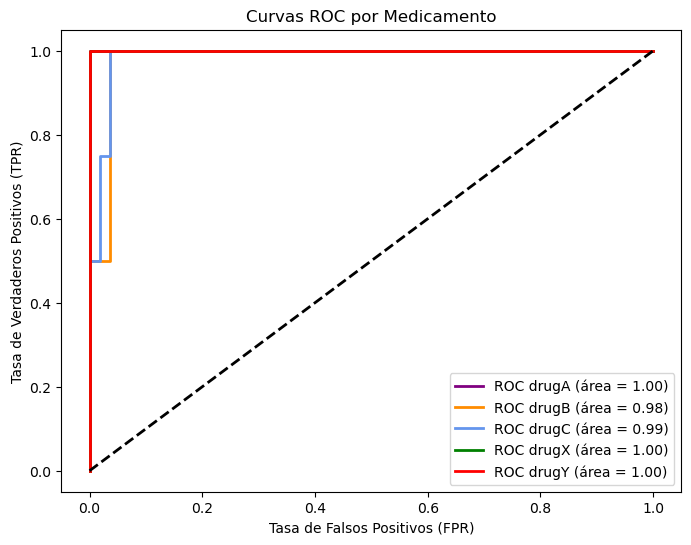

In [111]:
plt.figure(figsize=(8, 6))

colors = ['purple', 'darkorange', 'cornflowerblue', 'green', 'red']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {clf.classes_[i]} (área = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Línea diagonal de azar
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC por Medicamento')
plt.legend(loc="lower right")
plt.show()

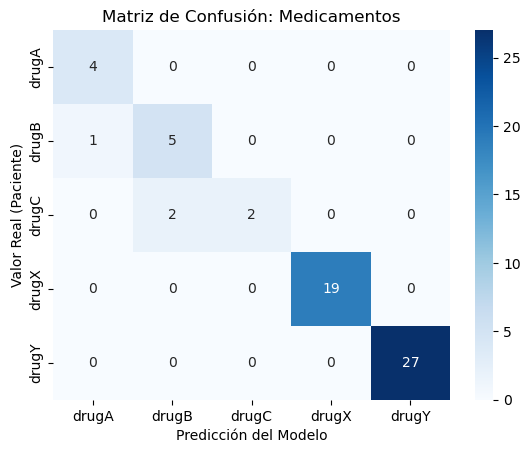

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Comparamos los valores reales (y_test) contra las predicciones (y_pred)
cm = confusion_matrix(y_test, y_pred)

# 2. La graficamos para que sea fácil de leer
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clf.classes_, 
            yticklabels=clf.classes_)

plt.title('Matriz de Confusión: Medicamentos')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Paciente)')
plt.show()